# EDA Part 1 (ml.m5.12xlarge)

In [1]:
import os
import pandas as pd
import numpy as np
import functions as func

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
Matplotlib is building the font cache; this may take a moment.


### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')
str_dirname_output = './output'

str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

list_cols_id = [
    str_id,
    str_datecol,
    str_target,
]

Project: 20231010-gen-xii
Step: 02_eda_pt_1


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [4]:
%%time

# import
str_filename = 'df_raw.gzip'
str_uri = f's3://{str_project}/01_ad/01_data_prep/01_data_collection/output/{str_filename}'
# read from s3
df = pd.read_parquet(str_uri)
# replace
df.replace(['NaN','nan'], np.nan, inplace=True)

# show
df

CPU times: user 2min 53s, sys: 5min 14s, total: 8min 8s
Wall time: 54.3 s


,bitdebtor__base,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,dtmfunded__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,...,us934d__tu,us934s__tu,us935b__tu,us935c__tu,us935d__tu,us935s__tu,score_bankcard__tu,score_cvpropensity__tu,finscore__tu,intscore__ln
0,0.0,20181103.0,20181103.0,NaN,NaN,201810.0,73140.0,2018-11-03,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,20181103.0,NaN,20181103.0,NaN,201810.0,72817.0,2018-11-03,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,20181103.0,NaN,20181103.0,NaN,201810.0,74494.0,2018-11-03,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,20181030.0,NaN,20181030.0,NaN,201810.0,61357.0,2018-10-30,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,20181031.0,20181031.0,NaN,NaN,201810.0,61417.0,2018-10-31,0.0,AU,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2100693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,NaN,555.0,588.0
2100694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,451.0,571.0,574.0
2100695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,447.0,616.0,568.0
2100696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.0,501.0,648.0,595.0


### Get data frame information

In [5]:
%%time

# get df info
str_filename = 'dict_df_info.json'
func.get_df_info(
    df=df, 
    str_datecol=str_datecol, 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)
print('')

{'date_max': '2019-12-31',
 'date_min': '2013-10-01',
 'flt_mean_target': 0.32045681959044087,
 'flt_propna': 0.24175835986641697,
 'int_ncols': 2488,
 'int_nrows': 2100698,
 'int_obs_total': 5226536624}

CPU times: user 15 s, sys: 781 ms, total: 15.8 s
Wall time: 15.8 s


### Get descriptives

In [6]:
%%time

str_filename = 'df_descriptives.csv'
list_cols = [col for col in df.columns if col not in list_cols_id]
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols], 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 2485/2485 [08:30<00:00,  4.87it/s]


CPU times: user 7min 52s, sys: 52.4 s, total: 8min 44s
Wall time: 8min 44s


### Get descriptives by ID columns

In [7]:
%%time

str_filename = 'df_descriptives_id.csv',
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols_id], 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 3/3 [00:42<00:00, 14.27s/it]

CPU times: user 42.8 s, sys: 20 ms, total: 42.8 s
Wall time: 42.9 s


### Plot proportion ```NaN```

CPU times: user 20.1 s, sys: 1.03 s, total: 21.1 s
Wall time: 21.1 s


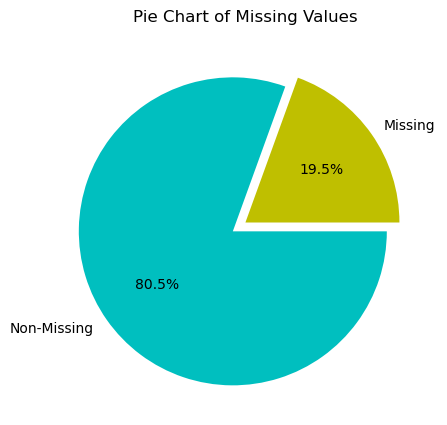

In [8]:
%%time

# plot proportion NaN
try:
    str_filename = 'plt_prop_nan.png',
    func.plot_proportion_nan(
        df=df,
        str_dirname_output=str_dirname_output,
        str_filename=str_filename,
    )
except:
    pass

### Plot data type frequency

100%|██████████| 2488/2488 [00:00<00:00, 7776.63it/s] 


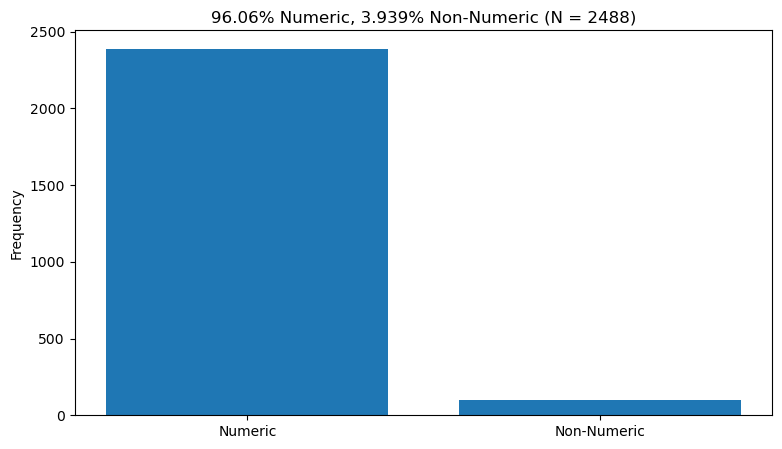

CPU times: user 896 ms, sys: 142 ms, total: 1.04 s
Wall time: 715 ms


In [9]:
%%time

# plot data type frequency
str_filename = 'plt_dtype.png'
func.plot_data_type_frequency(
    df=df,
    str_dirname_output=str_dirname_output,
    str_filename=str_filename,
)

### Plot target

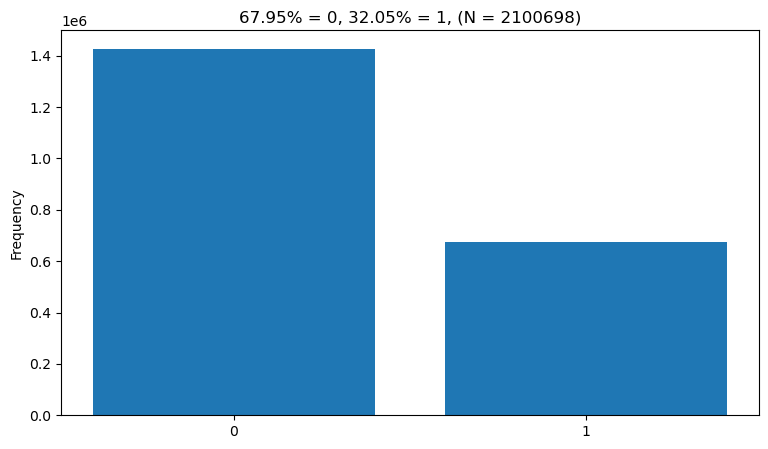

CPU times: user 486 ms, sys: 82.9 ms, total: 569 ms
Wall time: 352 ms


In [10]:
%%time

# plot target
str_filename = 'plt_target.png'
func.plot_target(
    ser_target=df[str_target],
    str_dirname_output=str_dirname_output,
    str_filename=str_filename,
)

## Write ```README.md``` to local drive

In [11]:
%%writefile README.md

A dictionary of data frame information is available [here](output/dict_df_info.json).

A data frame of descriptive statistics sorted descending by proportion missing by column is available [here](output/df_descriptives.csv).

A data frame of descriptive statistics sorted descending by proportion missing by ID column is available [here](output/df_descriptives_ids.csv).

A plot of percent missing overall in ```df_raw``` is shown below:

<p align="center"><img src="./output/plt_prop_nan.png" width=50% height=50% /></p>

A plot of data type frequency is shown below:
    
<p align="center"><img src="./output/plt_dtype.png" width=50% height=50% /></p>

Plots of the targets are shown below:
    
<p align="center"><img src="./output/plt_target.png" width=50% height=50% /></p>

Overwriting README.md
